# V5 ModernBERT input-representation OOD experiment

Notebook 04 showed a widening train/validation loss gap and routed only
truncated OOD test prompts. Notebook 05 tests whether missing context is a
cause, while keeping the evidence, split, safety loss, LoRA rank, seed,
calibration, gates, and five-epoch checkpoint rule fixed.

Three variants train against exactly the same prompt rows:

| Variant | Token budget | Retained context | Controlled question |
|---|---:|---|---|
| `prefix_512` | 512 | first 512 tokens | reproduces notebook-04 input |
| `prefix_1024` | 1,024 | first 1,024 tokens | does a larger budget help? |
| `head_tail_1024` | 1,024 | beginning + ending | does the discarded tail matter? |

The three models are launched concurrently on one GPU when the memory preflight
passes. Model initialization is serialized to avoid Hugging Face cache races;
training then overlaps. GPU RAM capacity enables concurrency but does not imply
a 3× speedup because all workers still share one compute device.

The active objective remains:

$$
\boxed{\mathcal L_{v5}=\mathcal L_{safety}+0.0\mathcal L_{oracle}}.
$$

Only the validation-selected representation opens the sealed test. Notebook 04
results are exploratory history and are not used to tune notebook 05 after its
test is opened.

## 1. Set up Colab

Use a GPU runtime for ModernBERT training. Qwen weights are never loaded.
Before running, open and accept access to the three auto-gated detail
datasets linked in section 3. Then click the key icon in Colab's left
sidebar, add a secret named exactly `HF_TOKEN`, paste a Hugging Face
read token as its value, and enable notebook access for that secret. If
the secret is absent, the next cell asks you to paste the token into a
hidden, session-only prompt instead of stopping with an exception.

In [1]:
%cd /content

from pathlib import Path

REPOSITORY_URL = "https://github.com/BrunoVitti96/LLM-router.git"
REPOSITORY_BRANCH = "poc"
PROJECT_ROOT = Path("/content/LLM_Router")

!test -d {PROJECT_ROOT} || git clone --branch {REPOSITORY_BRANCH} {REPOSITORY_URL} {PROJECT_ROOT}
!git -C {PROJECT_ROOT} fetch origin {REPOSITORY_BRANCH}
!git -C {PROJECT_ROOT} switch {REPOSITORY_BRANCH}
!git -C {PROJECT_ROOT} pull --ff-only origin {REPOSITORY_BRANCH}
%cd /content/LLM_Router
%pip install -q -U ".[notebook]"

import importlib
import sys

REQUIRED_EVIDENCE_HELPER = PROJECT_ROOT / "src/llm_router/qwen_evidence.py"
if not REQUIRED_EVIDENCE_HELPER.is_file():
    raise RuntimeError(
        f"Repository/source mismatch: {REQUIRED_EVIDENCE_HELPER} is missing. "
        f"Confirm that notebook 03 and branch {REPOSITORY_BRANCH!r} come from "
        "the same repository version, then rerun this setup cell."
    )

SOURCE_ROOT = str(PROJECT_ROOT / "src")
if SOURCE_ROOT not in sys.path:
    sys.path.insert(0, SOURCE_ROOT)
for module_name in list(sys.modules):
    if module_name == "llm_router" or module_name.startswith("llm_router."):
        del sys.modules[module_name]
importlib.invalidate_caches()
llm_router = importlib.import_module("llm_router")
print(
    f"Router package ready from {Path(llm_router.__file__).resolve()} "
    f"on branch {REPOSITORY_BRANCH!r}"
)


/content
Cloning into '/content/LLM_Router'...
remote: Enumerating objects: 511, done.
remote: Counting objects: 100% (511/511), done.
remote: Compressing objects: 100% (345/345), done.
remote: Total 511 (delta 273), reused 386 (delta 149), pack-reused 0 (from 0)
Receiving objects: 100% (511/511), 19.52 MiB | 23.77 MiB/s, done.
Resolving deltas: 100% (273/273), done.
From https://github.com/BrunoVitti96/LLM-router
 * branch            poc        -> FETCH_HEAD
Already on 'poc'
Your branch is up to date with 'origin/poc'.
From https://github.com/BrunoVitti96/LLM-router
 * branch            poc        -> FETCH_HEAD
Already up to date.
/content/LLM_Router
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

## 2. Freeze the v5 input-representation contract

Change only `RUN_ID` between v5 experiments. The three representations share
one evidence fingerprint, split, loss, optimizer settings, five epochs, and
validation gates. The default is dataset-OOD seed 42.

The parallel preflight requires a CUDA GPU with at least 14 GiB total memory
and 80% free before model construction. Otherwise the same variants run
sequentially. This fallback changes wall-clock execution, not the experiment.

In [2]:
import hashlib
import json
import os
import shutil
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import replace
from datetime import datetime, timezone
from getpass import getpass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from huggingface_hub import HfApi, hf_hub_download
from huggingface_hub.errors import GatedRepoError, HfHubHTTPError
from IPython.display import display
from transformers import AutoTokenizer

from llm_router.config import DEFAULT_CONFIG
from llm_router.experiment_comparison import (
    build_setup_comparison,
    choose_validation_setup,
    combine_threshold_searches,
)
from llm_router.hybrid_inference import (
    HybridModernBERTRouterRuntime,
    create_gradio_demo,
)
from llm_router.models.modernbert_router import (
    MODERNBERT_REFERENCE_COMPILE,
)
from llm_router.modernbert_poc import (
    export_modernbert_hybrid_poc,
    train_modernbert_hybrid_poc,
)
from llm_router.oracle import oracle_choices
from llm_router.public_benchmark import (
    EconomicsScenario,
    ModelProfile,
    export_public_benchmark,
    make_complete_panel,
    run_public_benchmark,
    select_validation_policy,
    simulate_economics,
    split_benchmark,
)
from llm_router.qwen_evidence import (
    BINARY_METRIC_PRIORITY,
    audit_aligned_outcomes,
    published_binary_score,
    validate_qwen_tier_contract,
)
from llm_router.router_overhead import benchmark_modernbert_overhead
from llm_router.utils.training import seed_everything

RUN_SPECS = {
    "qwen25_v5_context_random_seed_42": ("random", 42),
    "qwen25_v5_context_random_seed_43": ("random", 43),
    "qwen25_v5_context_random_seed_44": ("random", 44),
    "qwen25_v5_context_ood_seed_42": ("dataset_ood", 42),
    "qwen25_v5_context_ood_seed_43": ("dataset_ood", 43),
    "qwen25_v5_context_ood_seed_44": ("dataset_ood", 44),
}
RUN_ID = "qwen25_v5_context_ood_seed_42"
SPLIT_MODE, SEED = RUN_SPECS[RUN_ID]

MAX_PROMPTS_PER_TASK = 300
EVIDENCE_SAMPLE_SEED = 20260821
EPOCHS = 5
MINIMUM_EPOCHS = 5
EARLY_STOPPING_PATIENCE = None
MEASURE_ROUTER_OVERHEAD = True
LAUNCH_INTERACTIVE_DEMO = True
PARALLEL_TRAINING_REQUESTED = True
PARALLEL_MIN_TOTAL_GPU_GIB = 14.0
PARALLEL_MIN_FREE_FRACTION = 0.80
PARALLEL_BATCH_SIZE = 4
STEP_LOG_EVERY = 1
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
assert DEVICE == "cuda", "Choose Runtime > Change runtime type > GPU."

SETUP_SPECS = {
    "prefix_512": {
        "max_input_tokens": 512,
        "input_truncation_strategy": "prefix",
    },
    "prefix_1024": {
        "max_input_tokens": 1024,
        "input_truncation_strategy": "prefix",
    },
    "head_tail_1024": {
        "max_input_tokens": 1024,
        "input_truncation_strategy": "head_tail",
    },
}
V5_INPUT_CONTRACT = {
    "version": "v5-input-representation-parallel",
    "loss": "class-balanced fallback-relative safety BCE",
    "oracle_auxiliary_weight": 0.0,
    "lora_rank": 4,
    "lora_alpha": 8,
    "epochs": EPOCHS,
    "checkpoint_rule": "minimum validation safety loss",
    "parallel_training_requested": PARALLEL_TRAINING_REQUESTED,
    "modernbert_reference_compile": MODERNBERT_REFERENCE_COMPILE,
    "batch_size_per_variant": PARALLEL_BATCH_SIZE,
    "variants": SETUP_SPECS,
}
assert tuple(SETUP_SPECS) == (
    "prefix_512", "prefix_1024", "head_tail_1024"
)
assert EPOCHS == MINIMUM_EPOCHS == 5
assert EARLY_STOPPING_PATIENCE is None
assert MODERNBERT_REFERENCE_COMPILE is False

CANDIDATES = {
    "Qwen2.5-1.5B": {
        "model_repo": "Qwen/Qwen2.5-1.5B-Instruct",
        "model_revision": "989aa7980e4cf806f80c7fef2b1adb7bc71aa306",
        "parameters_billions": 1.54,
        "evidence_repo": "open-llm-leaderboard/Qwen__Qwen2.5-1.5B-Instruct-details",
        "evidence_revision": "801e825efda393dafd601fc9f9fa85646050f3b5",
        "evaluation_run": "2024-09-19T16-22-58.240552",
    },
    "Qwen2.5-3B": {
        "model_repo": "Qwen/Qwen2.5-3B-Instruct",
        "model_revision": "aa8e72537993ba99e69dfaafa59ed015b17504d1",
        "parameters_billions": 3.09,
        "evidence_repo": "open-llm-leaderboard/Qwen__Qwen2.5-3B-Instruct-details",
        "evidence_revision": "f5b005e407b8546e16de9349a82bbd40b0133abe",
        "evaluation_run": "2024-09-19T10-05-30.339220",
    },
    "Qwen2.5-7B": {
        "model_repo": "Qwen/Qwen2.5-7B-Instruct",
        "model_revision": "a09a35458c702b33eeacc393d103063234e8bc28",
        "parameters_billions": 7.61,
        "evidence_repo": "open-llm-leaderboard/Qwen__Qwen2.5-7B-Instruct-details",
        "evidence_revision": "98dea3336d741d4433976eeaf9e5125f39c45d5b",
        "evaluation_run": "2024-09-19T16-21-01.446061",
    },
}
validate_qwen_tier_contract(CANDIDATES)
SELECTED_MODELS = tuple(CANDIDATES)
EXCLUDED_OVERLAPPING_TASKS = {
    "leaderboard_gpqa_main",
    "leaderboard_gpqa_extended",
}

HF_TOKEN = os.environ.get("HF_TOKEN")
try:
    from google.colab import userdata
    from google.colab.userdata import (
        NotebookAccessError,
        SecretNotFoundError,
        TimeoutException,
    )

    if not HF_TOKEN:
        HF_TOKEN = userdata.get("HF_TOKEN")
except ImportError:
    pass
except (SecretNotFoundError, NotebookAccessError, TimeoutException) as secret_error:
    print(
        f"Colab secret unavailable ({type(secret_error).__name__}). "
        "Using a hidden session-only token prompt instead."
    )
if not HF_TOKEN:
    HF_TOKEN = getpass(
        "Paste your Hugging Face read token (input is hidden): "
    ).strip()
if not HF_TOKEN:
    raise RuntimeError(
        "No Hugging Face token was provided. Create a read token, accept "
        "access to the three gated datasets, and rerun this cell."
    )
try:
    hf_identity = HfApi().whoami(token=HF_TOKEN)
except HfHubHTTPError as token_error:
    raise RuntimeError(
        "Hugging Face rejected HF_TOKEN. Create a valid read token, "
        "enable notebook access, and rerun this cell."
    ) from token_error
print(
    "Hugging Face token accepted for "
    f"{hf_identity.get('name') or hf_identity.get('fullname') or 'the signed-in account'}."
)

evidence_contract = {
    "source": "Hugging Face Open LLM Leaderboard per-example detail datasets",
    "candidates": CANDIDATES,
    "max_prompts_per_task": MAX_PROMPTS_PER_TASK,
    "sampling_seed": EVIDENCE_SAMPLE_SEED,
    "excluded_overlapping_tasks": sorted(EXCLUDED_OVERLAPPING_TASKS),
    "correctness_policy": {
        "source": "published task-aware per-example metric",
        "metric_priority": BINARY_METRIC_PRIORITY,
        "required_values": [0, 1],
        "quality_formula": "correct / outcomes",
    },
    "candidate_latency": "analytical BF16; published runtime is unused",
}
EVIDENCE_TAG = hashlib.sha256(
    json.dumps(evidence_contract, sort_keys=True).encode("utf-8")
).hexdigest()[:16]
RUN_CONTRACT_TAG = hashlib.sha256(
    json.dumps(
        {
            "run_id": RUN_ID,
            "evidence_tag": EVIDENCE_TAG,
            "training": V5_INPUT_CONTRACT,
        },
        sort_keys=True,
    ).encode("utf-8")
).hexdigest()[:16]
OUTPUT_DIR = PROJECT_ROOT / "reports_benchmark" / RUN_ID

def log_stage(stage, **values):
    timestamp = datetime.now(timezone.utc).strftime("%H:%M:%S UTC")
    details = " | ".join(f"{key}={value}" for key, value in values.items())
    print(f"[{timestamp}] {stage}" + (f" | {details}" if details else ""))

seed_everything(SEED)
log_stage(
    "contracts frozen",
    run_id=RUN_ID,
    split=SPLIT_MODE,
    evidence_tag=EVIDENCE_TAG,
    run_contract_tag=RUN_CONTRACT_TAG,
    loss="safety-only",
    input_experiment="512-prefix vs 1024-prefix vs 1024-head-tail",
    parallel_requested=PARALLEL_TRAINING_REQUESTED,
    epochs=EPOCHS,
    gpu=torch.cuda.get_device_name(0),
)
display(pd.DataFrame(CANDIDATES).T)

Hugging Face token accepted for Pioppo.
[18:01:10 UTC] contracts frozen | run_id=qwen25_v5_context_ood_seed_42 | split=dataset_ood | evidence_tag=7bc81cd9a9ad2731 | run_contract_tag=cccc431ead439740 | loss=safety-only | input_experiment=512-prefix vs 1024-prefix vs 1024-head-tail | parallel_requested=True | epochs=5 | gpu=Tesla T4


,model_repo,model_revision,parameters_billions,evidence_repo,evidence_revision,evaluation_run
Qwen2.5-1.5B,Qwen/Qwen2.5-1.5B-Instruct,989aa7980e4cf806f80c7fef2b1adb7bc71aa306,1.54,open-llm-leaderboard/Qwen__Qwen2.5-1.5B-Instru...,801e825efda393dafd601fc9f9fa85646050f3b5,2024-09-19T16-22-58.240552
Qwen2.5-3B,Qwen/Qwen2.5-3B-Instruct,aa8e72537993ba99e69dfaafa59ed015b17504d1,3.09,open-llm-leaderboard/Qwen__Qwen2.5-3B-Instruct...,f5b005e407b8546e16de9349a82bbd40b0133abe,2024-09-19T10-05-30.339220
Qwen2.5-7B,Qwen/Qwen2.5-7B-Instruct,a09a35458c702b33eeacc393d103063234e8bc28,7.61,open-llm-leaderboard/Qwen__Qwen2.5-7B-Instruct...,98dea3336d741d4433976eeaf9e5125f39c45d5b,2024-09-19T16-21-01.446061


## 3. Download the published aligned Qwen answer datasets

Accept access to these auto-gated Hugging Face datasets before running:

- `open-llm-leaderboard/Qwen__Qwen2.5-1.5B-Instruct-details`
- `open-llm-leaderboard/Qwen__Qwen2.5-3B-Instruct-details`
- `open-llm-leaderboard/Qwen__Qwen2.5-7B-Instruct-details`

Each repository contains the same 39 evaluation tasks. V3 selects the
pinned evaluation run from each repository and excludes GPQA main and
extended because they overlap with GPQA Diamond. The remaining published
tasks include BBH, GPQA Diamond, IFEval, MATH-Hard categories, MMLU-Pro,
and MuSR.

The loader keeps the published rendered prompt, filtered response,
per-example metric, document hash, prompt hash, task name, and document
ID. It downloads JSONL evidence only—never Qwen weights. Each selected
metric must be exactly 0 (incorrect) or 1 (correct); a fractional or
ambiguous metric stops the run instead of silently becoming a label.

IFEval publishes loose and strict instruction- and prompt-level fields.
The frozen correctness rule explicitly selects its unsuffixed
`prompt_level_strict_acc` field. For example, loose prompt accuracy 1
and strict prompt accuracy 0 produces the conservative label 0.

In [3]:
def gated_dataset_error(repo_id, error):
    raise RuntimeError(
        f"Cannot read the gated evidence dataset {repo_id!r}. Open "
        f"https://huggingface.co/datasets/{repo_id}, sign in with the "
        "same account as HF_TOKEN, accept the dataset access conditions, "
        "and confirm that the token has Read access to gated repositories."
    ) from error

def list_evidence_files(spec):
    try:
        return HfApi().list_repo_files(
            spec["evidence_repo"],
            repo_type="dataset",
            revision=spec["evidence_revision"],
            token=HF_TOKEN,
        )
    except GatedRepoError as gated_error:
        gated_dataset_error(spec["evidence_repo"], gated_error)

def download_evidence_file(spec, filename):
    try:
        return hf_hub_download(
            repo_id=spec["evidence_repo"],
            filename=filename,
            repo_type="dataset",
            revision=spec["evidence_revision"],
            token=HF_TOKEN,
        )
    except GatedRepoError as gated_error:
        gated_dataset_error(spec["evidence_repo"], gated_error)

def first_string(value):
    if isinstance(value, str):
        return value
    if isinstance(value, dict):
        for nested in value.values():
            found = first_string(nested)
            if found is not None:
                return found
    if isinstance(value, (list, tuple)):
        for nested in value:
            found = first_string(nested)
            if found is not None:
                return found
    return None

def selected_sample_files(spec):
    files = list_evidence_files(spec)
    suffix = f"_{spec['evaluation_run']}.jsonl"
    selected = []
    for filename in files:
        basename = Path(filename).name
        if not basename.startswith("samples_") or not basename.endswith(suffix):
            continue
        task = basename[len("samples_") : -len(suffix)]
        if task not in EXCLUDED_OVERLAPPING_TASKS:
            selected.append((task, filename))
    return sorted(selected)

raw_rows = []
published_run_metadata = {}
task_sets = {}
for model_name, spec in CANDIDATES.items():
    task_files = selected_sample_files(spec)
    task_sets[model_name] = {task for task, _ in task_files}
    results_filename = str(
        Path(task_files[0][1]).parent
        / f"results_{spec['evaluation_run']}.json"
    )
    results_path = download_evidence_file(spec, results_filename)
    with open(results_path, encoding="utf-8") as handle:
        published_run_metadata[model_name] = json.load(handle)
    log_stage("published evidence download started", model=model_name, tasks=len(task_files))
    for task, filename in task_files:
        local_path = download_evidence_file(spec, filename)
        with open(local_path, encoding="utf-8") as handle:
            for line in handle:
                payload = json.loads(line)
                metric_name, score = published_binary_score(payload)
                prompt = first_string(payload.get("arguments"))
                if not prompt:
                    prompt = first_string(payload.get("doc"))
                if not prompt:
                    prompt = json.dumps(
                        payload.get("doc"), ensure_ascii=False, sort_keys=True
                    )
                response = first_string(payload.get("filtered_resps"))
                if response is None:
                    response = first_string(payload.get("resps")) or ""
                document_identity = str(payload.get("doc_hash") or "")
                if not document_identity:
                    document_identity = hashlib.sha256(
                        json.dumps(
                            payload.get("doc"),
                            ensure_ascii=False,
                            sort_keys=True,
                        ).encode("utf-8")
                    ).hexdigest()
                raw_rows.append(
                    {
                        "key": f"{task}::{payload['doc_id']}",
                        "task": task,
                        "doc_id": str(payload["doc_id"]),
                        "doc_hash": document_identity,
                        "prompt_hash": str(payload.get("prompt_hash", "")),
                        "target_hash": str(payload.get("target_hash", "")),
                        "prompt": prompt,
                        "prediction": response,
                        "target": json.dumps(
                            payload.get("target"), ensure_ascii=False, sort_keys=True
                        ),
                        "score": score,
                        "published_metric": metric_name,
                        "model": model_name,
                        "source_file": filename,
                        "evidence_repo": spec["evidence_repo"],
                        "evidence_revision": spec["evidence_revision"],
                    }
                )
    log_stage("published evidence loaded", model=model_name, rows=len(raw_rows))

assert len({frozenset(tasks) for tasks in task_sets.values()}) == 1, (
    "The pinned candidate evidence repositories do not expose identical task sets."
)
raw_records = pd.DataFrame(raw_rows)
assert raw_records.groupby(["key", "model"]).size().eq(1).all()
display(
    pd.DataFrame(
        {"model": task_sets.keys(), "published_tasks": map(len, task_sets.values())}
    )
)


results_2024-09-19T16-22-58.240552.json: 0.00B [00:00, ?B/s]

[18:01:10 UTC] published evidence download started | model=Qwen2.5-1.5B | tasks=37


(…)essions_2024-09-19T16-22-58.240552.jsonl: 0.00B [00:00, ?B/s]

(…)dgement_2024-09-19T16-22-58.240552.jsonl: 0.00B [00:00, ?B/s]

(…)tanding_2024-09-19T16-22-58.240552.jsonl: 0.00B [00:00, ?B/s]

...

(…)steries_2024-09-19T16-21-01.446061.jsonl: 0.00B [00:00, ?B/s]

(…)cements_2024-09-19T16-21-01.446061.jsonl: 0.00B [00:00, ?B/s]

(…)ocation_2024-09-19T16-21-01.446061.jsonl: 0.00B [00:00, ?B/s]

[18:02:30 UTC] published evidence loaded | model=Qwen2.5-7B | rows=61836


,model,published_tasks
0,Qwen2.5-1.5B,37
1,Qwen2.5-3B,37
2,Qwen2.5-7B,37


## 4. Align, sample, and audit the published outcomes

V3 retains only prompt keys present for all three models. It requires
document hashes and rendered prompts to agree across candidates. Sampling
is deterministic within each published task, and duplicate document hashes
are kept once globally so dataset-OOD splits cannot leak the same question
through two task variants.

Correctness comes from each benchmark's published task-aware grader. The
notebook does not try to re-grade heterogeneous tasks with a fragile text
comparison. It verifies that every score is binary, records it as the
boolean `is_correct`, and computes quality as `correct / outcomes`. For
example, 240 correct rows out of 300 give quality $240/300=80\%$.

The notebook downloads the pinned Qwen tokenizer only to count input and
output tokens. Tokenization is not model inference. Realized completion
length remains excluded from analytical latency.

In [4]:
model_count_by_key = raw_records.groupby("key").model.nunique()
complete_keys = set(model_count_by_key[model_count_by_key.eq(len(CANDIDATES))].index)
aligned = raw_records.loc[raw_records.key.isin(complete_keys)].copy()
assert not aligned.empty
assert aligned.groupby("key").doc_hash.nunique().le(1).all()
prompt_variants = aligned.groupby("key").prompt.nunique()
if not prompt_variants.le(1).all():
    raise ValueError(
        f"{int((prompt_variants > 1).sum())} keys have model-dependent prompts."
    )

canonical = (
    aligned.sort_values(["key", "model"])
    .drop_duplicates("key")
    [["key", "task", "doc_hash", "prompt"]]
)
selected_keys = []
seen_doc_hashes = set()
for task_index, (task, task_rows) in enumerate(
    canonical.groupby("task", sort=True), start=1
):
    task_rows = task_rows.loc[~task_rows.doc_hash.isin(seen_doc_hashes)]
    count = min(MAX_PROMPTS_PER_TASK, len(task_rows))
    rng = np.random.default_rng(EVIDENCE_SAMPLE_SEED + task_index)
    positions = np.sort(rng.choice(len(task_rows), size=count, replace=False))
    selected = task_rows.iloc[positions]
    selected_keys.extend(selected.key)
    seen_doc_hashes.update(selected.doc_hash)

records = aligned.loc[aligned.key.isin(selected_keys)].copy()
records["example_id"] = records.key
records["dataset"] = records.task.str.removeprefix("leaderboard_")
records["source_split"] = "published_evaluation"
records["recorded_cost"] = 0.0

tokenizer = AutoTokenizer.from_pretrained(
    CANDIDATES["Qwen2.5-7B"]["model_repo"],
    revision=CANDIDATES["Qwen2.5-7B"]["model_revision"],
    use_fast=True,
)
prompt_token_counts = {
    key: len(tokenizer.encode(prompt, add_special_tokens=False))
    for key, prompt in records.drop_duplicates("key")[["key", "prompt"]].itertuples(
        index=False, name=None
    )
}
records["prompt_tokens"] = records.key.map(prompt_token_counts).astype(int)
records["completion_tokens"] = [
    len(tokenizer.encode(str(value), add_special_tokens=False))
    for value in records.prediction
]
del tokenizer

expected_rows = len(selected_keys) * len(CANDIDATES)
assert len(records) == expected_rows
records, quality_audit = audit_aligned_outcomes(records, SELECTED_MODELS)
assert records.groupby("example_id").model.nunique().eq(len(CANDIDATES)).all()
assert records.score.eq(records.is_correct.astype(float)).all()
log_stage(
    "published evidence aligned",
    prompts=len(selected_keys),
    outcomes=len(records),
    tasks=records.dataset.nunique(),
    qwen_weights_loaded=False,
)
display(
    records.pivot_table(
        index="dataset", columns="model", values="score", aggfunc="mean"
    ).style.format("{:.1%}")
)
display(quality_audit)


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[18:03:07 UTC] published evidence aligned | prompts=8632 | outcomes=25896 | tasks=37 | qwen_weights_loaded=False


model,Qwen2.5-1.5B,Qwen2.5-3B,Qwen2.5-7B
dataset,,,
bbh_boolean_expressions,83.6%,76.8%,84.4%
bbh_causal_judgement,57.8%,62.6%,52.9%
bbh_date_understanding,41.2%,45.6%,56.4%
bbh_disambiguation_qa,47.2%,54.8%,62.8%
bbh_formal_fallacies,55.6%,50.0%,59.6%
bbh_geometric_shapes,19.6%,39.2%,51.6%
bbh_hyperbaton,66.0%,63.6%,52.0%
bbh_logical_deduction_five_objects,28.8%,41.2%,50.4%
bbh_logical_deduction_seven_objects,23.2%,40.4%,47.2%


,task,model,published_metric,outcomes,correct,incorrect,quality
0,leaderboard_bbh_boolean_expressions,Qwen2.5-1.5B,acc_norm,250,209,41,0.836000
1,leaderboard_bbh_boolean_expressions,Qwen2.5-3B,acc_norm,250,192,58,0.768000
2,leaderboard_bbh_boolean_expressions,Qwen2.5-7B,acc_norm,250,211,39,0.844000
3,leaderboard_bbh_causal_judgement,Qwen2.5-1.5B,acc_norm,187,108,79,0.577540
4,leaderboard_bbh_causal_judgement,Qwen2.5-3B,acc_norm,187,117,70,0.625668
...,...,...,...,...,...,...,...
106,leaderboard_musr_object_placements,Qwen2.5-3B,acc_norm,256,60,196,0.234375
107,leaderboard_musr_object_placements,Qwen2.5-7B,acc_norm,256,63,193,0.246094
108,leaderboard_musr_team_allocation,Qwen2.5-1.5B,acc_norm,250,97,153,0.388000
109,leaderboard_musr_team_allocation,Qwen2.5-3B,acc_norm,250,114,136,0.456000


## 5. Attach analytical latency and audit leakage

The panel rejects missing prompt/model pairs and duplicate content crossing
splits. Candidate latency is computed from parameter count, BF16 weight
precision, prompt size, expected output length, and dated hardware
assumptions. Published runtime and realized completion length are excluded.

For active parameters $P$, effective compute $F$, bandwidth $B$, and
precision $b$, the core terms are:

$$t_{compute/token}=\frac{2P}{F},\qquad
t_{memory/pass}=\frac{Pb/8}{B}.$$

The code multiplies every recorded completion length by 100 and requires
analytical latency to remain identical. That is the leakage check.

In [5]:
analytical_records = records.assign(
    formatted_prompt=records.prompt,
    ground_truth=records.target,
)
profiles = tuple(
    ModelProfile(
        name=name,
        input_price_per_million=0.0,
        output_price_per_million=0.0,
        parameters_billions=spec["parameters_billions"],
        active_parameters_billions=spec["parameters_billions"],
        architecture="autoregressive",
        weight_bits=16,
    )
    for name, spec in CANDIDATES.items()
)
scenario = EconomicsScenario(
    name="qwen25-three-tier-analytical-latency-poc",
    as_of="2026-08-21",
    profiles=profiles,
    latency_method="analytical",
    effective_tflops=60.0,
    memory_bandwidth_gbps=900.0,
    fixed_model_overhead_s=0.015,
    router_overhead_s=0.004,
    output_base_tokens=24.0,
    output_tokens_per_prompt_token=0.20,
    output_min_tokens=16,
    output_max_tokens=256,
    notes="Published Qwen answer evidence; analytical BF16 candidate latency only.",
)
simulated = simulate_economics(analytical_records, scenario)
panel = make_complete_panel(simulated, models=SELECTED_MODELS)

counterfactual = analytical_records.copy()
counterfactual["completion_tokens"] *= 100
counterfactual_simulated = simulate_economics(counterfactual, scenario)
assert np.allclose(
    simulated.simulated_latency_s,
    counterfactual_simulated.simulated_latency_s,
), "Leakage check failed: completion length changed analytical latency."

split = split_benchmark(panel, mode=SPLIT_MODE, seed=SEED)
split_indices = {"train": split.train, "validation": split.validation, "test": split.test}
prompt_hashes = {
    name: set(panel.examples.iloc[indices].prompt_hash)
    for name, indices in split_indices.items()
}
assert prompt_hashes["train"].isdisjoint(prompt_hashes["validation"])
assert prompt_hashes["train"].isdisjoint(prompt_hashes["test"])
assert prompt_hashes["validation"].isdisjoint(prompt_hashes["test"])
if SPLIT_MODE == "dataset_ood":
    assert set(split.train_datasets).isdisjoint(split.validation_datasets)
    assert set(split.train_datasets).isdisjoint(split.test_datasets)

quality_summary = records.groupby("model").is_correct.mean().rename("quality")
latency_summary = simulated.groupby("model").simulated_latency_s.mean().rename(
    "mean_analytical_latency_s"
)
panel_summary = pd.concat([quality_summary, latency_summary], axis=1)
panel_summary["latency_vs_7b"] = (
    panel_summary.mean_analytical_latency_s
    / panel_summary.loc["Qwen2.5-7B", "mean_analytical_latency_s"]
)
display(panel_summary.style.format("{:.2%}", subset=["quality", "latency_vs_7b"]))
display(
    pd.DataFrame(
        {
            "split": list(split_indices),
            "prompts": [len(indices) for indices in split_indices.values()],
        }
    )
)
log_stage(
    "Leakage check and split audit passed",
    complete_prompts=len(panel.examples),
    train=len(split.train),
    validation=len(split.validation),
    test=len(split.test),
)


,quality,mean_analytical_latency_s,latency_vs_7b
model,,,
Qwen2.5-1.5B,34.81%,0.506837,20.73%
Qwen2.5-3B,38.46%,1.001868,40.97%
Qwen2.5-7B,44.05%,2.445441,100.00%


,split,prompts
0,train,5274
1,validation,1685
2,test,1673


[18:03:10 UTC] Leakage check and split audit passed | complete_prompts=8632 | train=5274 | validation=1685 | test=1673


## 6. Verify validation-only outcome-oracle headroom

The outcome oracle remains a diagnostic upper bound, not a training loss. It
uses recorded outcomes to ask whether safe faster choices exist under several
analytical scenarios. If oracle savings are non-positive, no prompt-only safety
classifier can create routing opportunity.

This diagnostic does not activate the oracle head and does not change
`oracle_auxiliary_weight=0.0`.

In [6]:
def validation_oracle_metrics(candidate_panel):
    fallback_index = int(candidate_panel.score[split.train].mean(axis=0).argmax())
    choices = oracle_choices(
        candidate_panel.score,
        candidate_panel.latency,
        fallback_index=fallback_index,
    )
    indices = split.validation
    rows_index = np.arange(len(indices))
    selected = choices[indices]
    fallback_quality = candidate_panel.score[indices, fallback_index].mean()
    oracle_quality = candidate_panel.score[indices][rows_index, selected].mean()
    fallback_latency = candidate_panel.latency[indices, fallback_index].mean()
    oracle_latency = candidate_panel.latency[indices][rows_index, selected].mean()
    return {
        "fallback_model": candidate_panel.models[fallback_index],
        "quality_retention": oracle_quality / max(fallback_quality, 1e-12),
        "latency_savings": 1 - oracle_latency / fallback_latency,
        "fallback_usage": np.mean(selected == fallback_index),
    }

sensitivity_settings = {
    "balanced": {},
    "compute_conservative": {"effective_tflops": 40.0},
    "bandwidth_conservative": {"memory_bandwidth_gbps": 600.0},
    "larger_fixed_overhead": {"fixed_model_overhead_s": 0.050},
    "longer_outputs": {
        "output_base_tokens": 48.0,
        "output_tokens_per_prompt_token": 0.35,
    },
}
sensitivity_rows = []
for scenario_name, overrides in sensitivity_settings.items():
    variant = replace(scenario, name=scenario_name, **overrides)
    variant_records = simulate_economics(analytical_records, variant)
    variant_panel = make_complete_panel(variant_records, models=SELECTED_MODELS)
    sensitivity_rows.append(
        {"scenario": scenario_name, **validation_oracle_metrics(variant_panel)}
    )
sensitivity = pd.DataFrame(sensitivity_rows)
assert (sensitivity.latency_savings > 0).all(), (
    "No robust oracle headroom. Stop: this panel cannot support the routing claim."
)
display(sensitivity.style.format({"quality_retention": "{:.2%}", "latency_savings": "{:.2%}"}))


,scenario,fallback_model,quality_retention,latency_savings,fallback_usage
0,balanced,Qwen2.5-7B,127.55%,71.97%,0.091395
1,compute_conservative,Qwen2.5-7B,127.55%,72.00%,0.091395
2,bandwidth_conservative,Qwen2.5-7B,127.55%,72.11%,0.091395
3,larger_fixed_overhead,Qwen2.5-7B,127.55%,70.91%,0.091395
4,longer_outputs,Qwen2.5-7B,127.55%,71.40%,0.091395


## 7. Understand the controlled input experiment

The safety target and loss do not change. Only the encoded prompt changes.
`prefix` reproduces tokenizer truncation from the right. `head_tail` tokenizes
without truncation, then retains half of the budget from the beginning and half
from the end, including normal special tokens.

For a 1,600-token router input:

- `prefix_512` discards 1,088 tokens;
- `prefix_1024` discards 576 tokens;
- `head_tail_1024` keeps roughly 512 beginning and 512 ending tokens.

All three use the same safety-only objective, rank-4 LoRA, learning rates, split,
seed, and five epochs. Each restores its own minimum validation safety-loss
checkpoint before validation policy comparison.

## 8. Train three input representations concurrently

The memory preflight records total and free GPU memory. A T4 with sufficient
headroom launches three worker threads, each with batch size 4. Model downloads
and construction are serialized; optimization overlaps. If the preflight fails,
the notebook runs the exact same configurations sequentially.

ModernBERT's optional internal `torch.compile` reference path is explicitly
disabled. PyTorch's Dynamo/FX compiler state is not safe for these concurrent
worker threads; eager execution computes the same encoder equations without the
compile race. For example, three variants still train $3 	imes 5=15$ total
model-epochs, but none can enter a shared Dynamo graph-compilation state.

Step callbacks fire and print after every optimizer step. Each line includes the
variant name so the three interleaved parallel logs remain attributable. Epoch
summaries always print. Concurrency mode and memory facts are exported.

In [7]:
PRINT_LOCK = threading.Lock()
MODEL_INITIALIZATION_LOCK = threading.Lock()


def make_step_logger(setup_name):
    def report(row):
        step = int(row["step_in_epoch"])
        final_step = int(row["steps_per_epoch"])
        if step != 1 and step != final_step and step % STEP_LOG_EVERY:
            return
        with PRINT_LOCK:
            print(
                f"[{setup_name}] epoch={int(row['epoch'])}/{int(row['epochs'])} "
                f"step={step}/{final_step} "
                f"loss={row['step_total_loss']:.6f} "
                f"running={row['running_train_total_loss']:.6f}",
                flush=True,
            )
    return report


def make_epoch_logger(setup_name):
    def report(row):
        marker = "BEST" if row["is_best_epoch"] else "    "
        with PRINT_LOCK:
            print(
                f"[{setup_name}] epoch={int(row['epoch'])}/{EPOCHS} {marker} "
                f"train={row['train_total_loss']:.4f} "
                f"validation={row['validation_total_loss']:.4f} "
                f"best_epoch={int(row['best_epoch_so_far'])} "
                f"seconds={row['epoch_seconds']:.1f}"
            )
    return report


gpu_free_bytes, gpu_total_bytes = torch.cuda.mem_get_info()
gpu_total_gib = gpu_total_bytes / 2**30
gpu_free_gib = gpu_free_bytes / 2**30
gpu_free_fraction = gpu_free_bytes / gpu_total_bytes
PARALLEL_TRAINING_ENABLED = bool(
    PARALLEL_TRAINING_REQUESTED
    and gpu_total_gib >= PARALLEL_MIN_TOTAL_GPU_GIB
    and gpu_free_fraction >= PARALLEL_MIN_FREE_FRACTION
)
parallel_training_facts = {
    "requested": PARALLEL_TRAINING_REQUESTED,
    "enabled": PARALLEL_TRAINING_ENABLED,
    "gpu": torch.cuda.get_device_name(0),
    "total_gib": gpu_total_gib,
    "free_gib_before_training": gpu_free_gib,
    "free_fraction_before_training": gpu_free_fraction,
    "workers": len(SETUP_SPECS) if PARALLEL_TRAINING_ENABLED else 1,
    "batch_size_per_variant": PARALLEL_BATCH_SIZE,
}
display(pd.Series(parallel_training_facts, name="parallel training preflight"))

setup_configs = {
    setup_name: replace(
        DEFAULT_CONFIG,
        seed=SEED,
        lora_r=4,
        lora_alpha=8,
        max_input_tokens=spec["max_input_tokens"],
        input_truncation_strategy=spec["input_truncation_strategy"],
    )
    for setup_name, spec in SETUP_SPECS.items()
}


def train_variant(setup_name):
    spec = SETUP_SPECS[setup_name]
    setup_config = setup_configs[setup_name]
    log_stage("router training started", setup=setup_name, **spec)
    training = train_modernbert_hybrid_poc(
        panel,
        split,
        config=setup_config,
        epochs=EPOCHS,
        batch_size=PARALLEL_BATCH_SIZE,
        learning_rate=1e-4,
        head_learning_rate=2e-4,
        minimum_epochs=MINIMUM_EPOCHS,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        quality_epsilon=0.0,
        safety_loss_weight=1.0,
        oracle_auxiliary_weight=0.0,
        dataset_balanced_sampling=False,
        device=DEVICE,
        progress_callback=make_epoch_logger(setup_name),
        step_progress_callback=make_step_logger(setup_name),
        initialization_lock=MODEL_INITIALIZATION_LOCK,
    )
    assert training.epochs_completed == EPOCHS
    assert not training.stopped_early
    training.model.to("cpu")
    log_stage(
        "router training finished",
        setup=setup_name,
        best_epoch=training.best_epoch,
        truncation=f"{training.input_diagnostics['truncation_rate']:.2%}",
    )
    return training


trainings = {}
if PARALLEL_TRAINING_ENABLED:
    with ThreadPoolExecutor(max_workers=len(SETUP_SPECS)) as executor:
        futures = {
            executor.submit(train_variant, setup_name): setup_name
            for setup_name in SETUP_SPECS
        }
        for future in as_completed(futures):
            setup_name = futures[future]
            try:
                trainings[setup_name] = future.result()
            except RuntimeError as error:
                if "out of memory" in str(error).lower():
                    raise RuntimeError(
                        "Parallel training exhausted GPU memory. Restart the runtime, "
                        "set PARALLEL_TRAINING_REQUESTED=False, and rerun all cells."
                    ) from error
                raise
else:
    for setup_name in SETUP_SPECS:
        trainings[setup_name] = train_variant(setup_name)

trainings = {name: trainings[name] for name in SETUP_SPECS}
torch.cuda.empty_cache()
assert tuple(trainings) == tuple(SETUP_SPECS)

,parallel training preflight
requested,True
enabled,True
gpu,Tesla T4
total_gib,14.563171
free_gib_before_training,14.460754
free_fraction_before_training,0.992967
workers,3
batch_size_per_variant,4


[18:03:17 UTC] router training started | setup=prefix_512 | max_input_tokens=512 | input_truncation_strategy=prefix
[18:03:17 UTC] router training started | setup=prefix_1024 | max_input_tokens=1024 | input_truncation_strategy=prefix
[18:03:17 UTC] router training started | setup=head_tail_1024 | max_input_tokens=1024 | input_truncation_strategy=head_tail


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/596M [00:00<?, ?B/s]

[prefix_512] epoch=1/5 step=1/1319 loss=0.307776 running=0.307776
[prefix_512] epoch=1/5 step=2/1319 loss=0.297077 running=0.302426
[prefix_512] epoch=1/5 step=3/1319 loss=0.256618 running=0.287157


You're using a PreTrainedTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


A saída de streaming foi truncada nas últimas 5000 linhas.
[prefix_1024] epoch=4/5 step=948/1319 loss=0.134080 running=0.206993
[prefix_512] epoch=4/5 step=1005/1319 loss=0.124596 running=0.207848
[head_tail_1024] epoch=4/5 step=973/1319 loss=0.064706 running=0.207363
[prefix_1024] epoch=4/5 step=949/1319 loss=0.216147 running=0.207002
[prefix_512] epoch=4/5 step=1006/1319 loss=0.008416 running=0.207650
[head_tail_1024] epoch=4/5 step=974/1319 loss=0.201745 running=0.207357
[prefix_1024] epoch=4/5 step=950/1319 loss=0.313743 running=0.207115
[head_tail_1024] epoch=4/5 step=975/1319 loss=0.486944 running=0.207644
[prefix_512] epoch=4/5 step=1007/1319 loss=0.343901 running=0.207785
[prefix_1024] epoch=4/5 step=951/1319 loss=0.227793 running=0.207137
[head_tail_1024] epoch=4/5 step=976/1319 loss=0.164478 running=0.207600
[prefix_512] epoch=4/5 step=1008/1319 loss=0.207193 running=0.207784
[prefix_1024] epoch=4/5 step=952/1319 loss=0.242422 running=0.207174
[prefix_512] epoch=4/5 step=1009

## 9. Select one representation using validation only

Every representation receives independent calibration and threshold search on
the same validation prompts. The existing gate-aware selector chooses one setup;
the sealed test remains unopened. The table adds token budget, strategy, and
truncation rate so a lower loss cannot hide a more expensive input.

In [8]:
policy_kwargs = {
    "objective": "latency",
    "minimum_quality_retention": DEFAULT_CONFIG.minimum_quality_retention,
    "confidence": DEFAULT_CONFIG.quality_confidence,
    "validation_quality_margin": DEFAULT_CONFIG.validation_quality_margin,
    "minimum_predicted_savings": DEFAULT_CONFIG.minimum_predicted_speedup,
    "router_overhead_s": scenario.router_overhead_s,
    "conservative_router_overhead_s": DEFAULT_CONFIG.conservative_router_overhead_s,
    "minimum_macro_quality_retention": DEFAULT_CONFIG.minimum_macro_quality_retention,
    "maximum_quality_loss_rate_ucl": DEFAULT_CONFIG.maximum_quality_loss_rate_ucl,
    "minimum_routed_safety_precision_lcb": DEFAULT_CONFIG.minimum_routed_safety_precision_lcb,
    "minimum_guarded_dataset_quality_retention_lcb": (
        DEFAULT_CONFIG.minimum_guarded_dataset_quality_retention_lcb
    ),
    "minimum_guarded_dataset_prompts": DEFAULT_CONFIG.minimum_guarded_dataset_prompts,
    "minimum_consecutive_feasible_thresholds": (
        DEFAULT_CONFIG.minimum_consecutive_feasible_thresholds
    ),
    "seed": SEED,
}
selections = {}
for setup_name, training in trainings.items():
    selection = select_validation_policy(
        panel,
        split,
        routing_probabilities=training.safety_probabilities,
        router_name=f"modernbert_qwen_tier_router__{setup_name}",
        **policy_kwargs,
    )
    selections[setup_name] = selection
    log_stage(
        "validation policy evaluated",
        setup=setup_name,
        active=selection.router_active,
        threshold=selection.selected_threshold,
        reason="; ".join(selection.failure_reasons) or "all gates passed",
    )

setup_comparison = build_setup_comparison(trainings, selections)
setup_comparison['max_input_tokens'] = setup_comparison.setup.map(
    lambda name: SETUP_SPECS[name]['max_input_tokens']
)
setup_comparison['input_truncation_strategy'] = setup_comparison.setup.map(
    lambda name: SETUP_SPECS[name]['input_truncation_strategy']
)
setup_comparison['truncation_rate'] = setup_comparison.setup.map(
    lambda name: trainings[name].input_diagnostics['truncation_rate']
)
setup_threshold_search = combine_threshold_searches(selections)
display(
    setup_comparison.sort_values(
        ["router_active", "conservative_resource_savings"], ascending=False
    ).style.format(
        {
            "quality_retention_lcb": "{:.2%}",
            "routed_safety_precision_lcb": "{:.2%}",
            "safe_opportunity_recall": "{:.2%}",
            "routed_fraction": "{:.2%}",
            "nominal_resource_savings": "{:.2%}",
            "conservative_resource_savings": "{:.2%}",
        }
    )
)

SELECTED_SETUP = choose_validation_setup(setup_comparison)
setup_comparison["selected_for_test"] = setup_comparison.setup.eq(SELECTED_SETUP)
selected_training = trainings[SELECTED_SETUP]
selected_config = setup_configs[SELECTED_SETUP]
selected_spec = SETUP_SPECS[SELECTED_SETUP]
frozen_validation_policy = selections[SELECTED_SETUP]
log_stage(
    "POLICY FROZEN — sealed test may now open",
    setup=SELECTED_SETUP,
    active=frozen_validation_policy.router_active,
    threshold=frozen_validation_policy.selected_threshold,
    feasible_block=int(
        setup_comparison.set_index("setup").loc[
            SELECTED_SETUP, "feasible_block_size"
        ]
    ),
)

[20:36:00 UTC] validation policy evaluated | setup=prefix_512 | active=True | threshold=0.9 | reason=all gates passed
[20:36:00 UTC] validation policy evaluated | setup=prefix_1024 | active=True | threshold=0.9 | reason=all gates passed
[20:36:01 UTC] validation policy evaluated | setup=head_tail_1024 | active=True | threshold=0.915 | reason=all gates passed


,setup,router_active,selected_threshold,diagnostic_threshold,validation_total_loss,best_epoch,epochs_completed,dataset_balanced_sampling,training_minutes,calibrated_brier,calibrated_ece,safe_roc_auc,unsafe_average_precision,quality_retention_lcb,macro_quality_retention_lcb,quality_loss_rate_ucl,routed_safety_precision_lcb,guarded_dataset_retention_lcb,safe_opportunity_recall,routed_fraction,nominal_resource_savings,conservative_resource_savings,feasible_block_size,gate_pass_count,failure_reasons,max_input_tokens,input_truncation_strategy,truncation_rate
1,prefix_1024,True,0.900000,0.900000,0.240348,3,5,False,151.620366,0.127969,0.016740,0.569009,0.181320,99.35%,1.000000,0.005277,95.19%,0.946994,11.63%,10.80%,12.23%,11.54%,12,7,,1024,prefix,0.117354
0,prefix_512,True,0.900000,0.900000,0.241337,3,5,False,145.068333,0.128017,0.017047,0.561574,0.179900,99.46%,0.996556,0.003580,96.45%,0.959750,10.78%,9.91%,11.18%,10.49%,12,7,,512,prefix,0.642609
2,head_tail_1024,True,0.915000,0.915000,0.238605,3,5,False,150.080823,0.127864,0.015927,0.571203,0.180762,99.40%,0.993112,0.003580,95.97%,0.957978,9.47%,8.72%,9.82%,9.14%,10,7,,1024,head_tail,0.117354


[20:36:01 UTC] POLICY FROZEN — sealed test may now open | setup=prefix_1024 | active=True | threshold=0.9 | feasible_block=12


## 10. Measure ModernBERT overhead only

This measures tokenization, host-to-device transfer, and ModernBERT
inference on the named Colab GPU. It does not time any Qwen candidate and
cannot change the already-frozen threshold. The measured p50 and p95 are
compared with the eventual policy-specific break-even overhead.

In [9]:
router_overhead_benchmark = None
if MEASURE_ROUTER_OVERHEAD:
    validation_examples = panel.examples.iloc[split.validation]
    router_overhead_benchmark = benchmark_modernbert_overhead(
        selected_training.model,
        selected_training.tokenizer,
        validation_examples.prompt.to_numpy(),
        validation_examples.prompt_tokens.to_numpy(),
        device=DEVICE,
        max_input_tokens=selected_config.max_input_tokens,
        input_truncation_strategy=(
            selected_config.input_truncation_strategy
        ),
        timed_requests=min(100, len(validation_examples)),
        warmup_requests=10,
        seed=SEED,
    )
    measured = router_overhead_benchmark.summary["end_to_end_ms"]
    log_stage(
        "ModernBERT overhead measured",
        p50_ms=f"{measured['p50']:.2f}",
        p95_ms=f"{measured['p95']:.2f}",
        candidate_latency="analytical-only",
        policy_changed=False,
    )
    display(pd.DataFrame(router_overhead_benchmark.summary).loc[
        ["mean", "p50", "p95", "maximum"],
        ["end_to_end_ms", "model_only_ms"],
    ])

[20:36:11 UTC] ModernBERT overhead measured | p50_ms=45.99 | p95_ms=69.48 | candidate_latency=analytical-only | policy_changed=False


,end_to_end_ms,model_only_ms
mean,49.939591,46.480238
p50,45.992099,42.391204
p95,69.477927,64.157230
maximum,75.306045,73.609957


## 11. Open the sealed test exactly once

A non-trivial router passes only when every predeclared sealed-test safety
and savings gate passes. Fallback-only behavior is a safe operational
result, but it is not evidence that learned routing works.

In [10]:
result = run_public_benchmark(
    panel,
    split,
    routing_probabilities=selected_training.safety_probabilities,
    router_name="modernbert_qwen_tier_router",
    selected_setup=SELECTED_SETUP,
    decision_metadata={
        "router_input_tokens": selected_training.router_input_lengths,
        "router_was_truncated": selected_training.router_was_truncated,
        "router_input_max_tokens": np.full(
            len(panel.examples), selected_config.max_input_tokens
        ),
        "router_input_truncation_strategy": np.full(
            len(panel.examples), selected_config.input_truncation_strategy
        ),
    },
    **policy_kwargs,
)
assert result.selected_threshold == frozen_validation_policy.selected_threshold
assert result.router_active == frozen_validation_policy.router_active

router_metrics = result.summary.loc["modernbert_qwen_tier_router"]
routed = result.decisions.selected_model.ne(result.fallback_model)
gained = result.decisions.quality_delta.gt(0)
lost = result.decisions.quality_delta.lt(0)
log_stage(
    "sealed test complete",
    single_run_passed=result.single_run_passed,
    routed=f"{routed.mean():.2%}",
    gained=int(gained.sum()),
    lost=int(lost.sum()),
    net_answers=int(gained.sum() - lost.sum()),
    retention_lcb=f"{router_metrics.quality_retention_lcb:.2%}",
    savings_4ms=f"{router_metrics.resource_savings:.2%}",
    savings_20ms=f"{router_metrics.conservative_resource_savings:.2%}",
)
display(result.summary)
display(result.router_overhead_sensitivity)
if result.failure_reasons:
    print("Failure reasons:")
    for reason in result.failure_reasons:
        print("-", reason)

break_even_ms = float(
    result.router_overhead_sensitivity.break_even_router_overhead_ms.iloc[0]
)
overhead_rows = [
    {"source": "frozen nominal assumption", "overhead_ms": 4.0},
    {"source": "frozen conservative assumption", "overhead_ms": 20.0},
]
if router_overhead_benchmark is not None:
    measured = router_overhead_benchmark.summary["end_to_end_ms"]
    overhead_rows.extend(
        [
            {"source": "measured ModernBERT p50", "overhead_ms": measured["p50"]},
            {"source": "measured ModernBERT p95", "overhead_ms": measured["p95"]},
        ]
    )
overhead_comparison = pd.DataFrame(overhead_rows)
overhead_comparison["break_even_ms"] = break_even_ms
overhead_comparison["below_break_even"] = (
    overhead_comparison.overhead_ms < break_even_ms
)
display(overhead_comparison)

[20:36:11 UTC] sealed test complete | single_run_passed=False | routed=35.92% | gained=49 | lost=37 | net_answers=12 | retention_lcb=99.54% | savings_4ms=34.98% | savings_20ms=34.31%


,objective,selected_model,quality,fallback_quality,quality_retention,quality_retention_lcb,quality_loss_rate,quality_loss_rate_ucl,routed_safety_precision,routed_safety_precision_lcb,...,macro_dataset_count,guarded_dataset_quality_retention,guarded_dataset_quality_retention_lcb,guarded_dataset_count,mean_resource,fallback_resource,resource_savings,conservative_resource_savings,fallback_usage,oracle_savings_capture
best_single,latency,Qwen2.5-7B,0.426778,0.426778,1.000000,1.000000,0.000000,0.001615,1.000000,1.000000,...,5.0,1.000000,1.000000,5.0,2.385999,2.385999,0.000000,0.000000,1.000000,0.000000
cheapest_single,latency,Qwen2.5-1.5B,0.347878,0.426778,0.815126,0.761300,0.205619,0.222340,0.794381,0.777660,...,5.0,0.379845,0.246568,5.0,0.494808,2.385999,0.792620,0.792620,0.000000,1.128937
dataset_lookup,latency,dynamic,0.426778,0.426778,1.000000,1.000000,0.000000,0.001615,1.000000,1.000000,...,5.0,1.000000,1.000000,5.0,2.385999,2.385999,0.000000,0.000000,1.000000,0.000000
outcome_oracle,latency,dynamic,0.553497,0.426778,1.296919,1.265564,0.000000,0.001615,1.000000,0.998202,...,5.0,1.000000,1.000000,5.0,0.710803,2.385999,0.702094,0.702094,0.102212,1.000000
modernbert_qwen_tier_router,latency,dynamic,0.433951,0.426778,1.016807,0.995447,0.022116,0.028847,0.938436,0.920261,...,5.0,0.991071,0.813253,5.0,1.551306,2.385999,0.349829,0.343124,0.640765,0.498266


,router_overhead_ms,net_latency_savings,break_even_router_overhead_ms
0,4.0,0.349829,838.692677
1,10.0,0.347315,838.692677
2,20.0,0.343124,838.692677
3,50.0,0.330550,838.692677


Failure reasons:
- Sealed-test quality-loss rate exceeded its UCL gate.
- Sealed-test guarded-dataset quality missed its worst-group LCB gate.


,source,overhead_ms,break_even_ms,below_break_even
0,frozen nominal assumption,4.000000,838.692677,True
1,frozen conservative assumption,20.000000,838.692677,True
2,measured ModernBERT p50,45.992099,838.692677,True
3,measured ModernBERT p95,69.477927,838.692677,True


## 12. Diagnose OOD task mix, tier usage, and truncation

For dataset-OOD runs, every displayed test task was absent from training. The
detailed diagnostics expose net answers, quality retention, routing rate,
conservative analytical savings, selected-tier counts, and truncation. Random
runs still generate the same tables but must not be labeled OOD evidence.

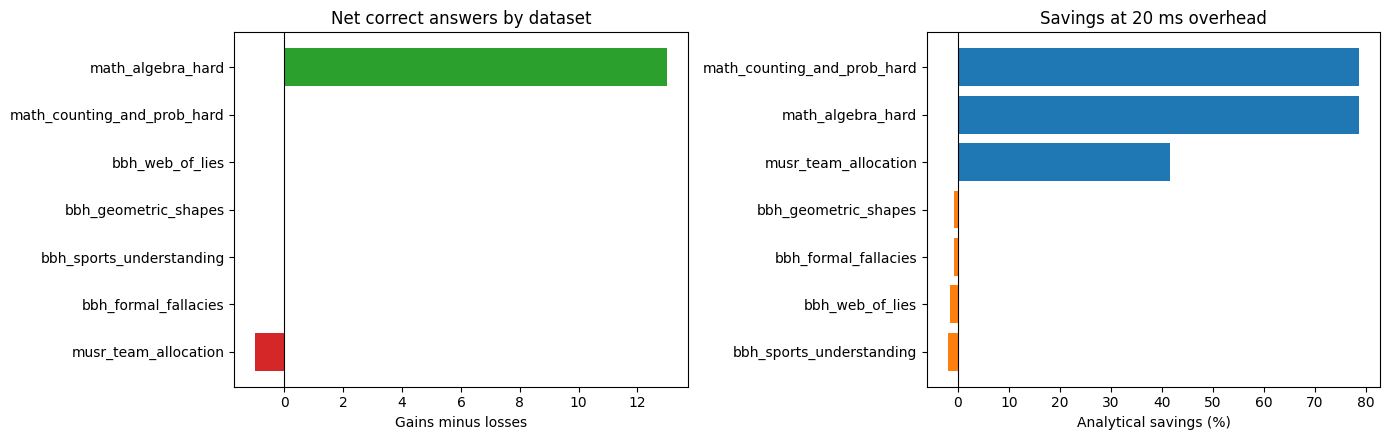

,prompts,routed,gains,losses,truncated,net_answers,routed_fraction,quality_retention,quality_retention_lcb,quality_loss_rate_ucl,routed_safety_precision_lcb,resource_savings,conservative_resource_savings
dataset,,,,,,,,,,,,,
musr_team_allocation,250,178,36,37,0,-1,0.712,9.910714e-01,8.653443e-01,0.188704,0.737917,0.420970,0.415533
bbh_formal_fallacies,250,0,0,0,0,0,0.000,1.000000e+00,1.000000e+00,0.010706,1.000000,-0.001685,-0.008424
bbh_sports_understanding,250,0,0,0,0,0,0.000,1.000000e+00,1.000000e+00,0.010706,1.000000,-0.004089,-0.020447
bbh_geometric_shapes,250,0,0,0,0,0,0.000,1.000000e+00,1.000000e+00,0.010706,1.000000,-0.001423,-0.007114
bbh_web_of_lies,250,0,0,0,0,0,0.000,1.000000e+00,1.000000e+00,0.010706,1.000000,-0.002949,-0.014743
math_counting_and_prob_hard,123,123,0,0,4,0,1.000,0.000000e+00,0.000000e+00,0.021523,0.978477,0.792749,0.787852
math_algebra_hard,300,300,13,0,9,13,1.000,4.333333e+10,2.396541e+10,0.008938,0.991062,0.792717,0.787789


,prompts,gains,losses
selected_model,,,
Qwen2.5-1.5B,423,13,0
Qwen2.5-3B,178,36,37
Qwen2.5-7B,1072,0,0


,prompts,routed,gains,losses
router_was_truncated,,,,
False,1660,588,49,37
True,13,13,0,0


In [11]:
decisions = result.decisions.assign(
    gained=gained,
    lost=lost,
    routed=routed,
)
dataset_outcomes = decisions.groupby("dataset").agg(
    prompts=("dataset", "size"),
    routed=("routed", "sum"),
    gains=("gained", "sum"),
    losses=("lost", "sum"),
    truncated=("router_was_truncated", "sum"),
)
dataset_outcomes["net_answers"] = (
    dataset_outcomes.gains - dataset_outcomes.losses
)
dataset_outcomes["routed_fraction"] = (
    dataset_outcomes.routed / dataset_outcomes.prompts
)
router_dataset_metrics = result.per_dataset_metrics.loc[
    result.per_dataset_metrics.strategy.eq("modernbert_qwen_tier_router")
].set_index("dataset")
dataset_outcomes = dataset_outcomes.join(
    router_dataset_metrics[
        [
            "quality_retention",
            "quality_retention_lcb",
            "quality_loss_rate_ucl",
            "routed_safety_precision_lcb",
            "resource_savings",
            "conservative_resource_savings",
        ]
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
net_order = dataset_outcomes.sort_values("net_answers")
axes[0].barh(
    net_order.index,
    net_order.net_answers,
    color=np.where(net_order.net_answers >= 0, "tab:green", "tab:red"),
)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set(title="Net correct answers by dataset", xlabel="Gains minus losses")
savings_order = dataset_outcomes.sort_values("conservative_resource_savings")
axes[1].barh(
    savings_order.index,
    100 * savings_order.conservative_resource_savings,
    color=np.where(
        savings_order.conservative_resource_savings >= 0,
        "tab:blue",
        "tab:orange",
    ),
)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set(title="Savings at 20 ms overhead", xlabel="Analytical savings (%)")
plt.tight_layout()
plt.show()

display(dataset_outcomes.sort_values("net_answers"))
display(
    decisions.groupby("selected_model").agg(
        prompts=("selected_model", "size"),
        gains=("gained", "sum"),
        losses=("lost", "sum"),
    )
)
display(
    decisions.groupby("router_was_truncated").agg(
        prompts=("dataset", "size"),
        routed=("routed", "sum"),
        gains=("gained", "sum"),
        losses=("lost", "sum"),
    )
)

## 13. Input-representation and selected-policy dashboard

The upper panels compare validation evidence before test selection: learning
curves, generalization gaps, and truncation. The lower panels show validation
routing economics and the selected setup's sealed OOD domain outcomes. Test
charts are descriptive and must not be used to retune notebook 05.

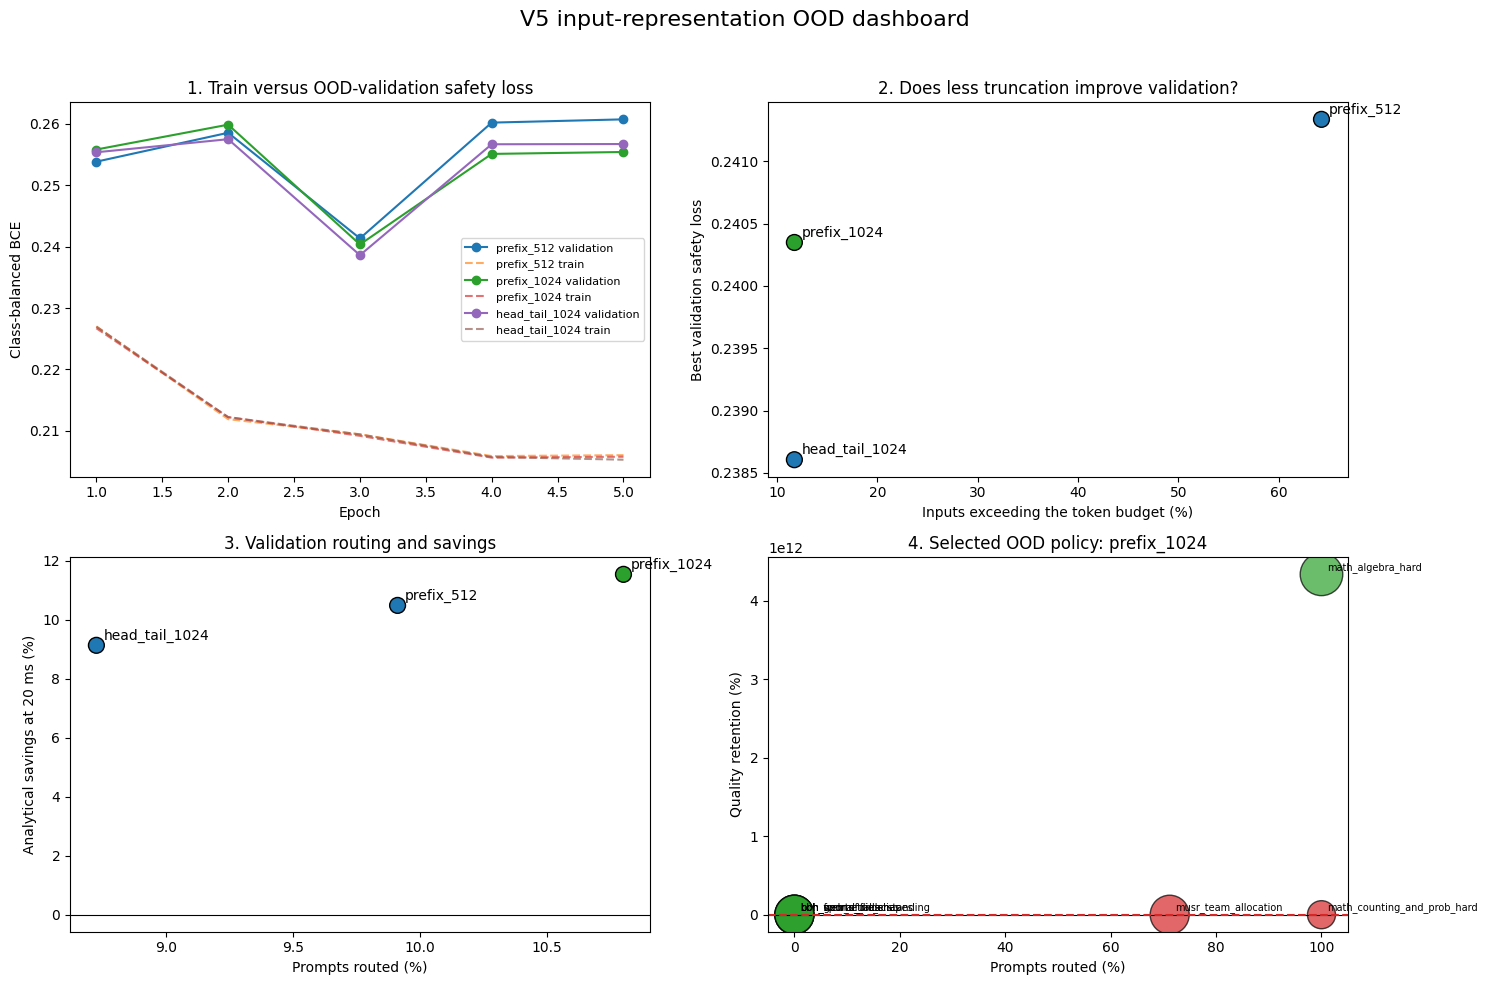

,setup,max_input_tokens,input_truncation_strategy,best_epoch,best_train_loss,best_validation_loss,generalization_gap,truncation_rate,safe_roc_auc,unsafe_average_precision,validation_routed_fraction,validation_conservative_savings,selected_for_test
2,head_tail_1024,1024,head_tail,3,0.209429,0.238605,0.029176,0.117354,0.571203,0.180762,0.087240,0.091367,False
1,prefix_1024,1024,prefix,3,0.209200,0.240348,0.031149,0.117354,0.569009,0.181320,0.108012,0.115438,True
0,prefix_512,512,prefix,3,0.209453,0.241337,0.031883,0.642609,0.561574,0.179900,0.099110,0.104903,False


,dataset,prompts,routed,gains,losses,truncated,net_answers,routed_fraction,quality_retention,quality_retention_lcb,quality_loss_rate_ucl,routed_safety_precision_lcb,resource_savings,conservative_resource_savings
5,math_counting_and_prob_hard,123,123,0,0,4,0,1.000,0.000000e+00,0.000000e+00,0.021523,0.978477,0.792749,0.787852
6,musr_team_allocation,250,178,36,37,0,-1,0.712,9.910714e-01,8.653443e-01,0.188704,0.737917,0.420970,0.415533
0,bbh_formal_fallacies,250,0,0,0,0,0,0.000,1.000000e+00,1.000000e+00,0.010706,1.000000,-0.001685,-0.008424
1,bbh_geometric_shapes,250,0,0,0,0,0,0.000,1.000000e+00,1.000000e+00,0.010706,1.000000,-0.001423,-0.007114
3,bbh_web_of_lies,250,0,0,0,0,0,0.000,1.000000e+00,1.000000e+00,0.010706,1.000000,-0.002949,-0.014743
2,bbh_sports_understanding,250,0,0,0,0,0,0.000,1.000000e+00,1.000000e+00,0.010706,1.000000,-0.004089,-0.020447
4,math_algebra_hard,300,300,13,0,9,13,1.000,4.333333e+10,2.396541e+10,0.008938,0.991062,0.792717,0.787789


In [12]:
representation_rows = []
for setup_name, training in trainings.items():
    best_row = training.history.loc[
        training.history.epoch.eq(training.best_epoch)
    ].iloc[0]
    comparison_row = setup_comparison.set_index("setup").loc[setup_name]
    representation_rows.append(
        {
            "setup": setup_name,
            "max_input_tokens": SETUP_SPECS[setup_name]["max_input_tokens"],
            "input_truncation_strategy": SETUP_SPECS[setup_name][
                "input_truncation_strategy"
            ],
            "best_epoch": training.best_epoch,
            "best_train_loss": best_row.train_safety_loss,
            "best_validation_loss": best_row.validation_safety_loss,
            "generalization_gap": (
                best_row.validation_safety_loss - best_row.train_safety_loss
            ),
            "truncation_rate": training.input_diagnostics["truncation_rate"],
            "safe_roc_auc": comparison_row.safe_roc_auc,
            "unsafe_average_precision": comparison_row.unsafe_average_precision,
            "validation_routed_fraction": comparison_row.routed_fraction,
            "validation_conservative_savings": (
                comparison_row.conservative_resource_savings
            ),
            "selected_for_test": setup_name == SELECTED_SETUP,
        }
    )
input_representation_comparison = pd.DataFrame(representation_rows)

investor_ood_dataset_summary = dataset_outcomes.reset_index().copy()
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for setup_name, training in trainings.items():
    axes[0, 0].plot(
        training.history.epoch,
        training.history.validation_safety_loss,
        marker="o",
        label=f"{setup_name} validation",
    )
    axes[0, 0].plot(
        training.history.epoch,
        training.history.train_safety_loss,
        linestyle="--",
        alpha=0.65,
        label=f"{setup_name} train",
    )
axes[0, 0].set(
    title="1. Train versus OOD-validation safety loss",
    xlabel="Epoch",
    ylabel="Class-balanced BCE",
)
axes[0, 0].legend(fontsize=8)

colors = np.where(
    input_representation_comparison.selected_for_test, "tab:green", "tab:blue"
)
axes[0, 1].scatter(
    100 * input_representation_comparison.truncation_rate,
    input_representation_comparison.best_validation_loss,
    s=130,
    c=colors,
    edgecolor="black",
)
for row in input_representation_comparison.itertuples():
    axes[0, 1].annotate(
        row.setup,
        (100 * row.truncation_rate, row.best_validation_loss),
        xytext=(5, 4),
        textcoords="offset points",
    )
axes[0, 1].set(
    title="2. Does less truncation improve validation?",
    xlabel="Inputs exceeding the token budget (%)",
    ylabel="Best validation safety loss",
)

axes[1, 0].scatter(
    100 * input_representation_comparison.validation_routed_fraction,
    100 * input_representation_comparison.validation_conservative_savings,
    s=130,
    c=colors,
    edgecolor="black",
)
for row in input_representation_comparison.itertuples():
    axes[1, 0].annotate(
        row.setup,
        (
            100 * row.validation_routed_fraction,
            100 * row.validation_conservative_savings,
        ),
        xytext=(5, 4),
        textcoords="offset points",
    )
axes[1, 0].axhline(0, color="black", linewidth=0.8)
axes[1, 0].set(
    title="3. Validation routing and savings",
    xlabel="Prompts routed (%)",
    ylabel="Analytical savings at 20 ms (%)",
)

domain_plot = investor_ood_dataset_summary.replace([np.inf, -np.inf], np.nan)
domain_plot = domain_plot.dropna(subset=["quality_retention"])
axes[1, 1].scatter(
    100 * domain_plot.routed_fraction,
    100 * domain_plot.quality_retention,
    s=40 + 3 * domain_plot.prompts,
    c=np.where(
        domain_plot.quality_retention_lcb
        >= DEFAULT_CONFIG.minimum_macro_quality_retention,
        "tab:green",
        "tab:red",
    ),
    alpha=0.7,
    edgecolor="black",
)
axes[1, 1].axhline(100, color="black", linewidth=0.8)
axes[1, 1].axhline(98, color="tab:red", linestyle="--")
for row in domain_plot.itertuples():
    axes[1, 1].annotate(
        row.dataset,
        (100 * row.routed_fraction, 100 * row.quality_retention),
        fontsize=7,
        xytext=(4, 3),
        textcoords="offset points",
    )
axes[1, 1].set(
    title=f"4. Selected OOD policy: {SELECTED_SETUP}",
    xlabel="Prompts routed (%)",
    ylabel="Quality retention (%)",
)

fig.suptitle("V5 input-representation OOD dashboard", fontsize=16)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()
investor_ood_figure = fig
display(input_representation_comparison.sort_values("best_validation_loss"))
display(investor_ood_dataset_summary.sort_values("quality_retention_lcb"))

## 14. Export the reconstructable v5 artifact

The ZIP records all three input representations, concurrency preflight, per-
variant histories and input diagnostics, validation comparison, selected sealed
test, OOD dashboard, selected adapter, and interactive runtime. The selected
artifact stores both token budget and truncation strategy.

In [14]:
report_dir = export_public_benchmark(result, scenario, OUTPUT_DIR)
sensitivity.to_csv(report_dir / "validation_sensitivity.csv", index=False)
setup_comparison.to_csv(report_dir / "setup_comparison.csv", index=False)
setup_threshold_search.to_csv(
    report_dir / "setup_threshold_search.csv", index=False
)
records.to_parquet(report_dir / "qwen_candidate_records.parquet", index=False)
quality_audit.to_csv(report_dir / "qwen_quality_audit.csv", index=False)
panel_summary.to_csv(report_dir / "qwen_candidate_panel_summary.csv")
(report_dir / "qwen_evidence_contract.json").write_text(
    json.dumps(
        {**evidence_contract, "evidence_tag": EVIDENCE_TAG},
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)
(report_dir / "published_evaluation_metadata.json").write_text(
    json.dumps(published_run_metadata, indent=2, sort_keys=True),
    encoding="utf-8",
)
for setup_name, training in trainings.items():
    setup_dir = report_dir / "setup_diagnostics" / setup_name
    setup_dir.mkdir(parents=True, exist_ok=True)
    training.history.to_csv(setup_dir / "training_history.csv", index=False)
    training.calibration_diagnostics.to_csv(
        setup_dir / "calibration_diagnostics.csv", index=False
    )
    (setup_dir / "input_diagnostics.json").write_text(
        json.dumps(training.input_diagnostics, indent=2), encoding="utf-8"
    )

artifact_dir = export_modernbert_hybrid_poc(
    selected_training,
    panel.models,
    report_dir / "modernbert_router",
    selected_threshold=result.selected_threshold,
    router_active=result.router_active,
    poc_passed=result.single_run_passed,
    failure_reasons=result.failure_reasons,
    minimum_predicted_savings=DEFAULT_CONFIG.minimum_predicted_speedup,
    validation_quality_margin=DEFAULT_CONFIG.validation_quality_margin,
    minimum_macro_quality_retention=DEFAULT_CONFIG.minimum_macro_quality_retention,
    maximum_quality_loss_rate_ucl=DEFAULT_CONFIG.maximum_quality_loss_rate_ucl,
    minimum_routed_safety_precision_lcb=(
        DEFAULT_CONFIG.minimum_routed_safety_precision_lcb
    ),
    minimum_guarded_dataset_quality_retention_lcb=(
        DEFAULT_CONFIG.minimum_guarded_dataset_quality_retention_lcb
    ),
    minimum_guarded_dataset_prompts=DEFAULT_CONFIG.minimum_guarded_dataset_prompts,
    conservative_router_overhead_s=DEFAULT_CONFIG.conservative_router_overhead_s,
    minimum_consecutive_feasible_thresholds=(
        DEFAULT_CONFIG.minimum_consecutive_feasible_thresholds
    ),
    benchmark_fingerprint=result.benchmark_fingerprint,
    setup_name=SELECTED_SETUP,
    oracle_auxiliary_weight=V5_INPUT_CONTRACT["oracle_auxiliary_weight"],
    router_overhead_benchmark=(
        router_overhead_benchmark.summary
        if router_overhead_benchmark is not None
        else None
    ),
    config=selected_config,
)
overhead_comparison.to_csv(
    report_dir / "modernbert_overhead_comparison.csv", index=False
)
input_representation_comparison.to_csv(
    report_dir / "input_representation_comparison.csv", index=False
)
(report_dir / "parallel_training_facts.json").write_text(
    json.dumps(parallel_training_facts, indent=2), encoding="utf-8"
)
investor_ood_dataset_summary.to_csv(
    report_dir / "investor_ood_dataset_summary.csv", index=False
)
investor_ood_figure.savefig(
    report_dir / "investor_ood_dashboard.png", dpi=180, bbox_inches="tight"
)
(report_dir / "v5_input_representation_contract.json").write_text(
    json.dumps(
        {
            **V5_INPUT_CONTRACT,
            "run_id": RUN_ID,
            "run_contract_tag": RUN_CONTRACT_TAG,
            "best_epoch": selected_training.best_epoch,
            "epochs_completed": selected_training.epochs_completed,
            "selected_setup": SELECTED_SETUP,
            "parallel_training": parallel_training_facts,
        },
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)
if router_overhead_benchmark is not None:
    router_overhead_benchmark.export(report_dir)

bundle_path = shutil.make_archive(str(OUTPUT_DIR.resolve()), "zip", root_dir=OUTPUT_DIR)
print("Reports:", report_dir)
print("Router artifact:", artifact_dir)
print("ZIP:", bundle_path)
try:
    from google.colab import files

    files.download(bundle_path)
except ImportError:
    pass

Reports: /content/LLM_Router/reports_benchmark/qwen25_v5_context_ood_seed_42
Router artifact: /content/LLM_Router/reports_benchmark/qwen25_v5_context_ood_seed_42/modernbert_router
ZIP: /content/LLM_Router/reports_benchmark/qwen25_v5_context_ood_seed_42.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 15. Interpretation checklist and interactive showcase

Before attributing improvement to truncation:

- confirm the three variants used identical evidence, split, loss, seed, LoRA,
  optimizer rates, batch size, and five epochs;
- confirm concurrency mode and GPU memory facts were exported;
- compare both truncation rate and validation loss—not training loss alone;
- require improved validation ROC-AUC/unsafe precision, not only calibration;
- open the sealed test for the validation-selected representation only;
- inspect selected test routing by truncation status and dataset;
- treat a parallel single-seed winner as exploratory until repeated; and
- never claim measured Qwen latency or production savings.

The final cell launches the selected representation using the same prefix or
head-tail encoder used during training.

In [15]:
# Interactive investor showcase — intentionally the final notebook cell.
demo_runtime = HybridModernBERTRouterRuntime.from_training_result(
    selected_training,
    model_names=panel.models,
    fallback_model=result.fallback_model,
    selected_threshold=result.selected_threshold,
    router_active=result.router_active,
    minimum_predicted_savings=DEFAULT_CONFIG.minimum_predicted_speedup,
    scenario=scenario,
    config=selected_config,
    device=DEVICE,
)
demo = create_gradio_demo(demo_runtime)
if LAUNCH_INTERACTIVE_DEMO:
    demo.launch(share=True, debug=False, prevent_thread_lock=True)
demo

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://73467028aae1b10e0c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Gradio Interface for: evaluate
------------------------------
inputs:
|-<gradio.components.textbox.Textbox object at 0x7e71dbee92b0>
|-<gradio.components.number.Number object at 0x7e71b9f4fe00>
outputs:
|-<gradio.components.json_component.JSON object at 0x7e71b9f94050>